# XGBoost para Regresión

En Google Colab no es necesario instalar nada

Para instalar el xgboost:
En un entorno local que use Anaconda, abrir Anaconda Prompt
```
anaconda search -t conda xgboost
conda install -c mndrake xgboost
```
Si la opcion anterior no funciona correctamente, existe la siguiente opcion:
```
conda install -c anaconda py-xgboost
```
Es normal que tarde un buen rato.

## Importar XGBoost

In [4]:
from xgboost import plot_importance
import xgboost as xgb

**XGBoost (eXtreme Gradient Boosting)** es una biblioteca de aprendizaje automático de código abierto que implementa el algoritmo de potenciación de gradiente, un método de boosting que utiliza árboles de decisión para tareas de clasificación y regresión.

Cada nuevo árbol intenta corregir los errores cometidos por los árboles anteriores, lo que resulta en un modelo final más preciso. XGBoost se destaca por su capacidad para manejar grandes conjuntos de datos y evitar el sobreajuste, además de su velocidad de entrenamiento y su capacidad para ser paralelizado.

**Características clave de XGBoost**:

- Potenciación de gradiente: XGBoost utiliza el método de potenciación de gradiente, donde cada árbol intenta minimizar la pérdida del modelo anterior.
- Árboles de decisión: Los modelos base en XGBoost son árboles de decisión, que son estructuras jerárquicas que dividen los datos en función de las características.
- Eficiencia: XGBoost está optimizado para ser rápido y eficiente, permitiendo el entrenamiento en grandes conjuntos de datos y utilizando recursos computacionales de manera efectiva.
- Regularización: XGBoost incluye técnicas de regularización para prevenir el sobreajuste, como la penalización de la complejidad del árbol y la reducción proporcional de nodos hoja.
- Paralelización: XGBoost puede aprovechar múltiples núcleos de CPU y GPUs para acelerar el proceso de entrenamiento.
- Manejo de datos escasos: XGBoost puede manejar datos con características escasas de manera eficiente.

**¿Cuándo usar XGBoost?**

XGBoost es una buena opción para problemas de aprendizaje supervisado que involucran: Grandes conjuntos de datos, Características numéricas y categóricas, Necesidad de un modelo preciso y eficiente, Tareas de clasificación y regresión.

## Cargar los datos

In [5]:
import pandas as pd
data = pd.read_csv("/content/sample_data/hormigon.csv")

In [6]:
descripcion = data.describe(include = "all").T
print(descripcion)

               count        mean         std     min      25%      50%  \
cement        1030.0  281.167864  104.506364  102.00  192.375  272.900   
slag          1030.0   73.895825   86.279342    0.00    0.000   22.000   
ash           1030.0   54.188350   63.997004    0.00    0.000    0.000   
water         1030.0  181.567282   21.354219  121.80  164.900  185.000   
superplastic  1030.0    6.204660    5.973841    0.00    0.000    6.400   
coarseagg     1030.0  972.918932   77.753954  801.00  932.000  968.000   
fineagg       1030.0  773.580485   80.175980  594.00  730.950  779.500   
age           1030.0   45.662136   63.169912    1.00    7.000   28.000   
strength      1030.0   35.817961   16.705742    2.33   23.710   34.445   

                   75%     max  
cement         350.000   540.0  
slag           142.950   359.4  
ash            118.300   200.1  
water          192.000   247.0  
superplastic    10.200    32.2  
coarseagg     1029.400  1145.0  
fineagg        824.000   992

In [7]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [8]:
X = data.drop('strength', axis=1)
y = data['strength']

## Separación train y test

In [9]:
# Corrección para la normalización
from sklearn.preprocessing import StandardScaler

# Primero dividir los datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

## Normalización

In [10]:
# Luego normalizar (usando sólo estadísticas del train)
scaler = StandardScaler()
X_train_no_escalado = X_train.copy()
X_test_no_escalado = X_test.copy()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)  # ¡No usar fit aquí!

Visualizamos que en test las medias y las desviaciones no son perfectamente 0 ni 1 ya que hemos usado las medias y desviaciones del train para normalizar, emulando lo que ocurriría en condiciones normales con datos nuevos.

In [11]:
X_train = pd.DataFrame(X_train, columns=X_train_no_escalado.columns)
X_test = pd.DataFrame(X_test, columns=X_test_no_escalado.columns)
X_test.describe().T

,count,mean,std,min,25%,50%,75%,max
cement,258.0,0.042654,0.938366,-1.546290,-0.636621,-0.132297,0.657182,2.450595
slag,258.0,-0.151092,0.906225,-0.876859,-0.876859,-0.706549,0.515140,3.203764
ash,258.0,0.092727,1.000025,-0.824195,-0.824195,-0.824195,1.025834,2.303495
water,258.0,-0.091617,1.003874,-2.826717,-0.882238,0.114629,0.466465,3.046593
superplastic,258.0,0.031292,1.005259,-1.032262,-1.032262,-0.026469,0.706921,4.365493
coarseagg,258.0,0.038797,1.039269,-2.223657,-0.521854,-0.041192,0.880509,2.106197
fineagg,258.0,0.078386,0.969366,-2.204559,-0.314532,0.106575,0.661135,2.732299
age,258.0,-0.018972,0.981111,-0.676967,-0.613940,-0.283049,0.158139,5.026962


# Modelo XGBoost

In [12]:
# Definimos el modelo con todos sus parametros
xgb_model = xgb.XGBRegressor(base_score=1,
                             colsample_bylevel=0.8,
                             colsample_bytree=0.8,
                             gamma=0,
                             learning_rate=0.1,
                             max_delta_step=0,
                             max_depth=3,
                             min_child_weight=1,
                             missing=1,
                             n_estimators=200,
                             objective='reg:squarederror',
                             reg_alpha=0,
                             reg_lambda=1,
                             scale_pos_weight=1,
                             seed=0,
                             subsample=1,
                             random_state=42)

## Con validación cruzada

In [13]:
from warnings import filterwarnings
filterwarnings('ignore')

Primero validación cruzada con datos de entrenamiento

In [14]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(xgb_model, X_train, y_train, cv=5)
print("Cross-val R² scores:", scores)
print("Mean CV R²:", scores.mean())

Cross-val R² scores: [0.91322145 0.9487102  0.86405571 0.94152254 0.90795771]
Mean CV R²: 0.9150935229015988


## Modelo final

Luego entrenar el modelo final con una partición concreta

In [15]:
# 2. Luego entrenar el modelo final
final_model = xgb_model.fit(X_train, y_train)

# 3. Evaluar en test set
test_score = final_model.score(X_test, y_test)
print("Test R²:", test_score)

Test R²: 0.9118270603487724


In [16]:
# El ultimo paso es determinar la importancia de cada una de las variables
importancias = pd.DataFrame(xgb_model.feature_importances_)
importancias.index = (X.columns)
print(importancias.sort_values(by=0, ascending=False))

                     0
age           0.322351
cement        0.204904
water         0.111565
superplastic  0.105746
ash           0.087749
slag          0.074533
fineagg       0.060459
coarseagg     0.032693


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

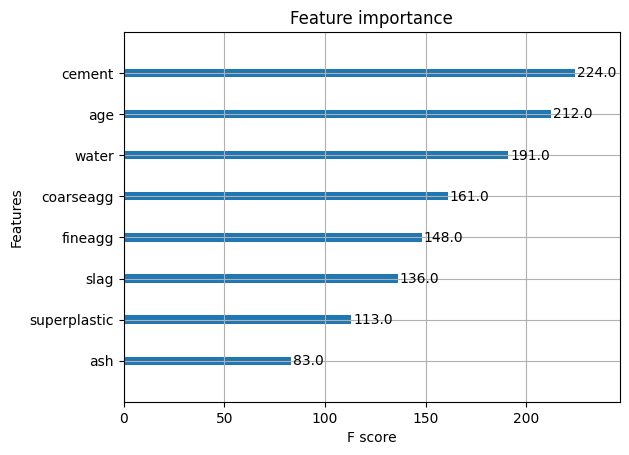

In [17]:
plot_importance(xgb_model)

## Grid Search de parámetros

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

# Resultados
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor score (CV):", grid_search.best_score_)

# Evaluar en test set
best_model = grid_search.best_estimator_
test_score = best_model.score(X_test, y_test)
print("Test R² con mejor modelo:", test_score)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Mejores parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
Mejor score (CV): 0.9245002751932171
Test R² con mejor modelo: 0.9310535271435307


Resultado:
> Fitting 5 folds for each of 108 candidates, totalling 540 fits
>
> - Mejores parámetros: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300, 'subsample': 1.0}
> - Mejor score (CV): 0.9245002751932171
> - Test R² con mejor modelo: 0.9310535271435307

Si ahora quisiera entrenar otro modelo con los parámetros óptimos encontrados podría hacerlo con todo `X` e `y` normalizados con la media y varianza de todo el dataset

# $${\color{red}{Modelo \space Final}}$$



In [18]:
# Luego normalizar (usando sólo estadísticas del train)
scaler = StandardScaler()

X_escalado = scaler.fit_transform(X)
import pickle
pickle.dump(scaler, open('scaler.pkl', 'wb'))
print(X_escalado)

[[-1.33901711  1.60144087 -0.84714393 ... -0.01439767 -0.31296991
  -0.27973311]
 [-1.07479007 -0.36754132  1.09607803 ...  1.38814131  0.28226038
  -0.50146528]
 [-0.29838379 -0.85688789  0.64896501 ... -0.20612089  1.09337085
  -0.27973311]
 ...
 [-0.04564488  0.4882354   0.56454507 ... -1.32300514 -0.06589318
  -0.27973311]
 [ 0.58237302 -0.41624406 -0.84714393 ... -0.52651741 -1.29254178
   3.55306569]
 [ 2.47791487 -0.85688789 -0.84714393 ...  1.9568773  -2.00382326
  -0.61233136]]


In [19]:
# Luego entrenar el modelo final
xgb_model = xgb.XGBRegressor(base_score=1,
                             colsample_bylevel=0.8,
                             colsample_bytree=0.8, # óptimo según el gridsearch
                             gamma=0,
                             learning_rate=0.2, # óptimo según el gridsearch
                             max_delta_step=0,
                             max_depth=3, # óptimo según el gridsearch
                             min_child_weight=1,
                             missing=1,
                             n_estimators=300, # óptimo según el gridsearch
                             objective='reg:squarederror',
                             reg_alpha=0,
                             reg_lambda=1,
                             scale_pos_weight=1,
                             seed=0,
                             subsample=1.0,  # óptimo según el gridsearch
                             random_state=42)

final_model = xgb_model.fit(X_escalado, y)

# Evaluar en train
train_score = final_model.score(X_escalado, y)
print("Test R²:", train_score)

Test R²: 0.9824083968378913


Este valor de R² es muy alto. Seguramente haya algo de Overfitting. Sin embargo, guardamos el modelo para reutilizarlo.

In [20]:
pickle.dump(final_model, open('final_model.pkl', 'wb'))

Cuando importemos el modelo y el scaler podemos hacer predicciones.

In [1]:
import pickle

In [2]:
escalador = pickle.load(open('scaler.pkl', 'rb'))
modelo = pickle.load(open('final_model.pkl', 'rb'))

In [23]:
X.head(2)

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age
0,141.3,212.0,0.0,203.5,0.0,971.8,748.5,28
1,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,14


In [3]:
nuevo_hormigon = {'cement': '168',
                  'slag': '42.2',
                  'ash': '124.3',
                  'water': '158.3',
                  'superplastic': '10.8',
                  'coarseagg': '1080.8',
                  'fineagg': '796.2',
                  'age': '14'}

In [4]:
nuevo_hormigon = {'cement': '141.0',
                  'slag': '212',
                  'ash': '0',
                  'water': '203.5',
                  'superplastic': '0',
                  'coarseagg': '971.8',
                  'fineagg': '748.5',
                  'age': '28'}

In [5]:
# Convertimos los values del diccionario en float:
for key, value in nuevo_hormigon.items():
    nuevo_hormigon[key] = float(value)

In [6]:
nuevo_hormigon

{'cement': 141.0,
 'slag': 212.0,
 'ash': 0.0,
 'water': 203.5,
 'superplastic': 0.0,
 'coarseagg': 971.8,
 'fineagg': 748.5,
 'age': 28.0}

In [8]:
import pandas as pd

In [9]:
nuevo_hormigon_df = pd.DataFrame(nuevo_hormigon, index=[0])

In [10]:
nuevo_hormigon_df.dtypes

,0
cement,float64
slag,float64
ash,float64
water,float64
superplastic,float64
coarseagg,float64
fineagg,float64
age,float64


In [11]:
# Ahora lo podemos normalizar:
nuevo_hormigon_escalado = escalador.transform(nuevo_hormigon_df)

In [12]:
# Y hacemos la predicción
prediccion = modelo.predict(nuevo_hormigon_escalado)

In [13]:
prediccion

array([28.639996], dtype=float32)

In [14]:
y[0]

NameError: name 'y' is not defined